In [43]:
import os
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.stats import sigma_clipped_stats

In [5]:
def load_trim(f):
    data = fits.getdata(f).astype(float)
    return data[:, :2048]

In [37]:
# --- Step 1: CCD Linearity Test ---

linearity_files = [
    "a039.fits",
    "a041.fits",
    "a045.fits",
    "a050.fits",
    "a047.fits",
    "a052.fits",
    "a053.fits",
    "a054.fits",
    "a055.fits",
    "a057.fits",
    "a059.fits"
]

exposure_times = []
adu_values = []

for f in linearity_files:
    hdr = fits.getheader(f)
    data = load_trim(f)
    
    mean, median, std = sigma_clipped_stats(data, sigma=3.0)

    exposure_times.append(hdr["EXPTIME"])
    adu_values.append(median)

exposure_times = np.array(exposure_times)
adu_values = np.array(adu_values)

# sort
idx = np.argsort(exposure_times)
exposure_times = exposure_times[idx]
adu_values = adu_values[idx]

print(exposure_times)
print(adu_values)

[  4.   6.  12.  15.  20.  25.  30.  40.  50.  80. 120.]
[27627. 30332. 28760. 15599. 35424. 17916. 18376. 19726. 19475. 25032.
 22795.]


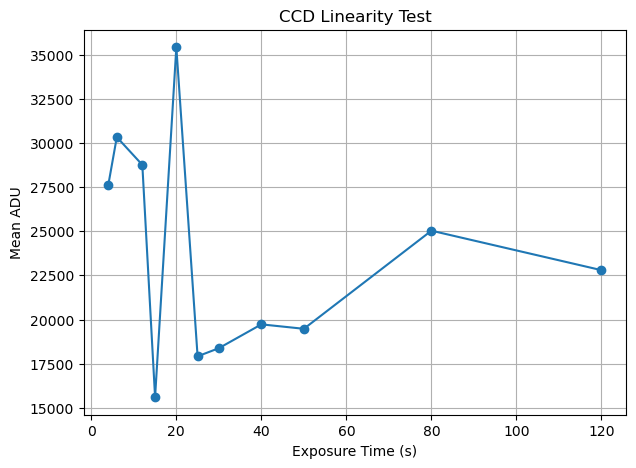

In [39]:
plt.figure(figsize=(7,5))
plt.plot(exposure_times, adu_values, 'o-')
plt.xlabel("Exposure Time (s)")
plt.ylabel("Mean ADU")
plt.title("CCD Linearity Test")
plt.grid(True)
plt.show()

In [13]:
for f in linearity_files:
    hdr = fits.getheader(f)
    print(f, hdr["EXPTIME"])

a039.fits 4.0
a041.fits 6.0
a045.fits 12.0
a050.fits 15.0
a047.fits 20.0
a052.fits 25.0
a053.fits 30.0
a054.fits 40.0
a055.fits 50.0
a057.fits 80.0
a059.fits 120.0


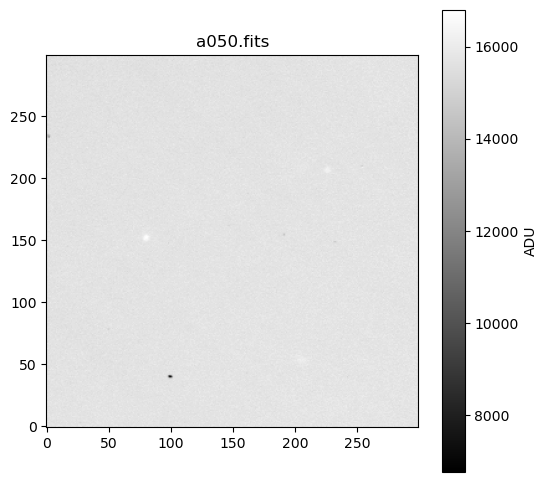

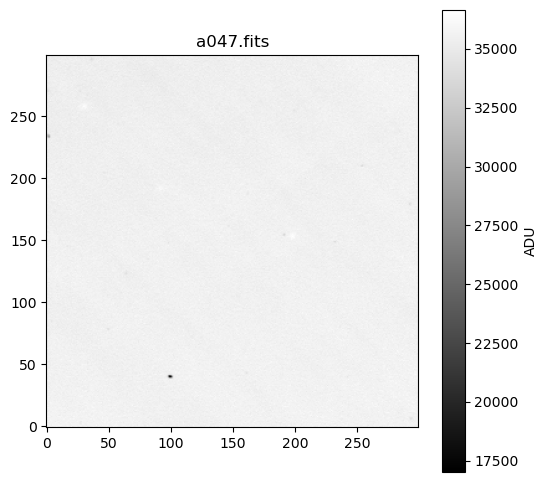

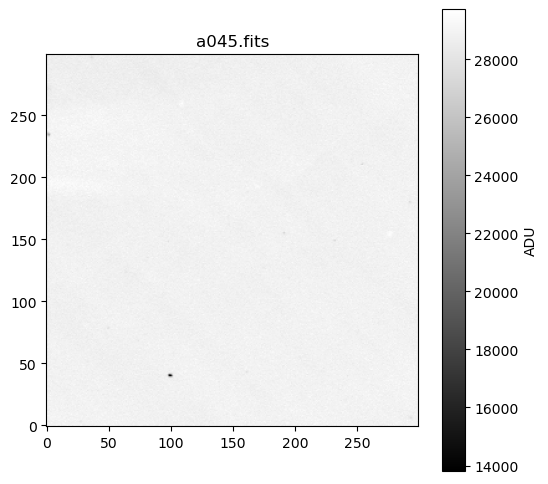

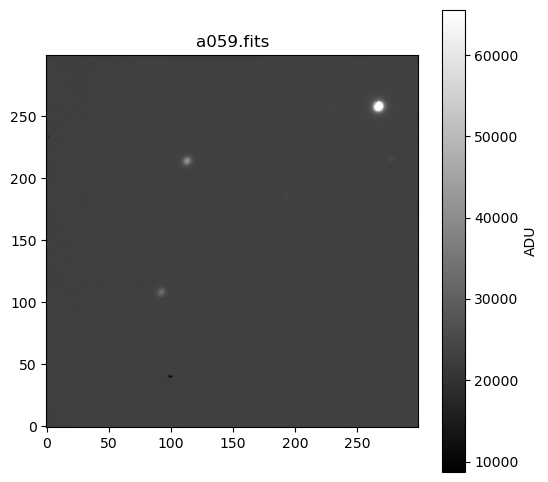

In [26]:
for f in ["a050.fits", "a047.fits", "a045.fits", "a059.fits"]:
    data = load_trim(f)
    plt.figure(figsize=(6,6))
    plt.imshow(data[1100:1400, 200:500], origin="lower", cmap="gray")
    plt.colorbar(label="ADU")
    plt.title(f)
    plt.show()

## CCD linearity test
To test CCD linearity, I measured the ADU values in a selected image region for a sequence of increasing exposure times. In an ideal CCD, the ADU should increase linearly with exposure time.

However, the resulting plot does not show a linear trend. I tested different statistics (mean, median, and sigma-clipped values) and different regions, but the behavior remained inconsistent.

This suggests that the data are affected by additional factors such as stars in the field, background structure, or instrumental effects, preventing a clean linear response. Therefore, the CCD does not appear linear over this dataset.

In [45]:
for file in sorted(os.listdir()):
    if file.endswith(".fits"):
        hdr = fits.getheader(file)
        obj = hdr.get("OBJECT")
        exptime = hdr.get("EXPTIME")
        filt = hdr.get("FILTER")
        print(file, "OBJECT =", obj, "FILTER =", filt, "EXPTIME =", exptime)

a001.fits OBJECT = SERVICE FILTER = None EXPTIME = 3.0
a002.fits OBJECT = SERVICE FILTER = None EXPTIME = 3.0
a003.fits OBJECT = SERVICE FILTER = None EXPTIME = 1.0
a004.fits OBJECT = SERVICE FILTER = None EXPTIME = 1.0
a005.fits OBJECT = SERVICE FILTER = None EXPTIME = 1.0
a006.fits OBJECT = SERVICE FILTER = None EXPTIME = 1.0
a007.fits OBJECT = SERVICE FILTER = None EXPTIME = 1.0
a008.fits OBJECT = SERVICE FILTER = None EXPTIME = 1.0
a009.fits OBJECT = SERVICE FILTER = None EXPTIME = 1.0
a010.fits OBJECT = SERVICE FILTER = None EXPTIME = 1.0
a011.fits OBJECT = SERVICE FILTER = None EXPTIME = 2.0
a012.fits OBJECT = SERVICE FILTER = None EXPTIME = 2.0
a013.fits OBJECT = SERVICE FILTER = None EXPTIME = 2.0
a014.fits OBJECT = SERVICE FILTER = None EXPTIME = 2.0
a015.fits OBJECT = SERVICE FILTER = None EXPTIME = 3.0
a016.fits OBJECT = SERVICE FILTER = None EXPTIME = 3.0
a017.fits OBJECT = SERVICE FILTER = None EXPTIME = 3.0
a018.fits OBJECT = SERVICE FILTER = None EXPTIME = 3.0
a019.fits 

a154.fits OBJECT = SERVICE FILTER = None EXPTIME = 6.0
a155.fits OBJECT = SERVICE FILTER = None EXPTIME = 6.0
a156.fits OBJECT = SERVICE FILTER = None EXPTIME = 1.0
a157.fits OBJECT = SERVICE FILTER = None EXPTIME = 1.0
a158.fits OBJECT = SERVICE FILTER = None EXPTIME = 6.0
a159.fits OBJECT = SERVICE FILTER = None EXPTIME = 12.0
a160.fits OBJECT = SERVICE FILTER = None EXPTIME = 12.0
a161.fits OBJECT = SERVICE FILTER = None EXPTIME = 12.0
a162.fits OBJECT = SERVICE FILTER = None EXPTIME = 20.0
a163.fits OBJECT = SERVICE FILTER = None EXPTIME = 20.0
a165.fits OBJECT = SERVICE FILTER = None EXPTIME = 60.0
a166.fits OBJECT = SERVICE FILTER = None EXPTIME = 30.0
a167.fits OBJECT = SERVICE FILTER = None EXPTIME = 30.0
a168.fits OBJECT = SERVICE FILTER = None EXPTIME = 10.0
a169.fits OBJECT = SERVICE FILTER = None EXPTIME = 10.0
a170.fits OBJECT = SERVICE FILTER = None EXPTIME = 5.0
a171.fits OBJECT = SERVICE FILTER = None EXPTIME = 5.0
a172.fits OBJECT = SERVICE FILTER = None EXPTIME = 5.0


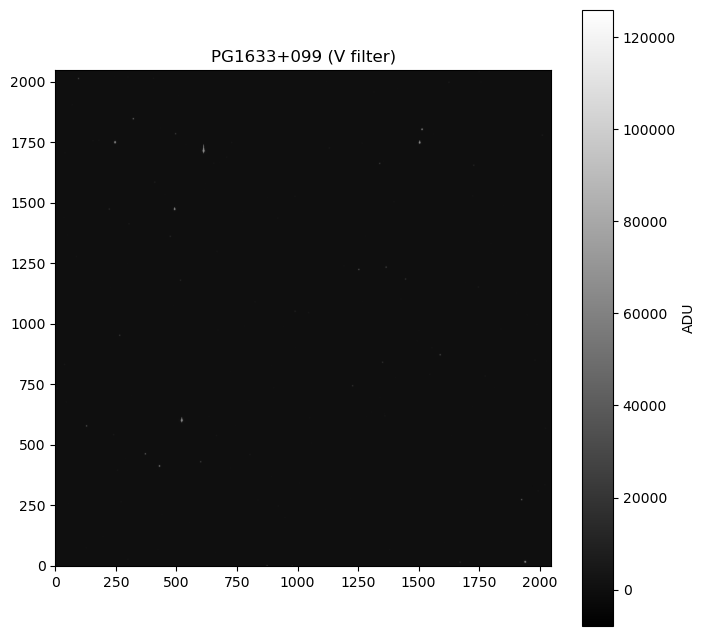

In [46]:
img = load_trim("a085otzf.fits")

plt.figure(figsize=(8,8))
plt.imshow(img, origin="lower", cmap="gray")
plt.colorbar(label="ADU")
plt.title("PG1633+099 (V filter)")
plt.show()

/var/folders/ts/c93yzbxx29jby3pvmc175s900000gn/T/ipykernel_75368/94791762.py:4: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  coords = plt.ginput(3)


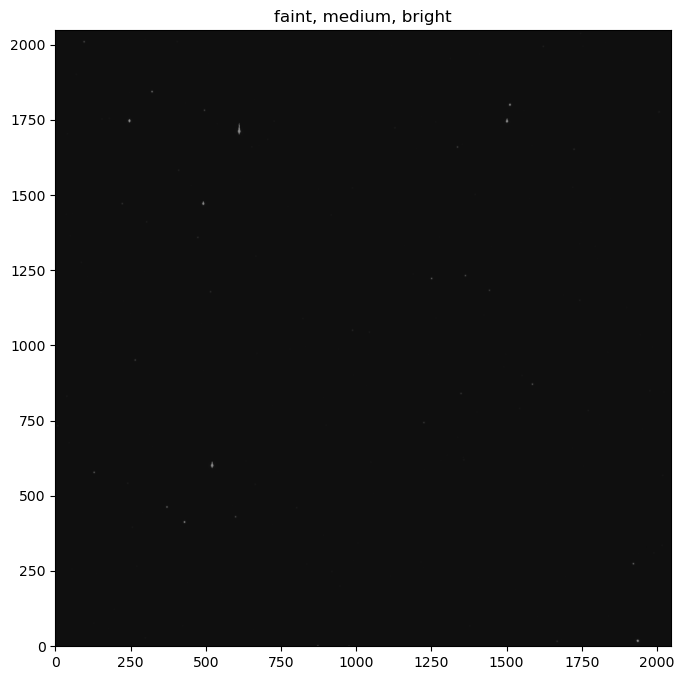

[]


In [50]:
plt.figure(figsize=(8,8))
plt.imshow(img, origin="lower", cmap="gray")
plt.title("faint, medium, bright")
coords = plt.ginput(3)
plt.show()

print(coords)

In [57]:
from photutils.aperture import CircularAperture, CircularAnnulus, aperture_photometry
import numpy as np

positions = [(1900, 200), (500, 450), (900, 1700)]

aperture = CircularAperture(positions, r=6)
annulus = CircularAnnulus(positions, r_in=10, r_out=15)

phot = aperture_photometry(img, aperture)
bkg = aperture_photometry(img, annulus)

bkg_mean = bkg['aperture_sum'] / annulus.area
bkg_total = bkg_mean * aperture.area

flux = phot['aperture_sum'] - bkg_total

print("Final flux:", flux)

Final flux:    aperture_sum   
------------------
 39.51088547307518
3.8142870707852126
 61.20915017716652


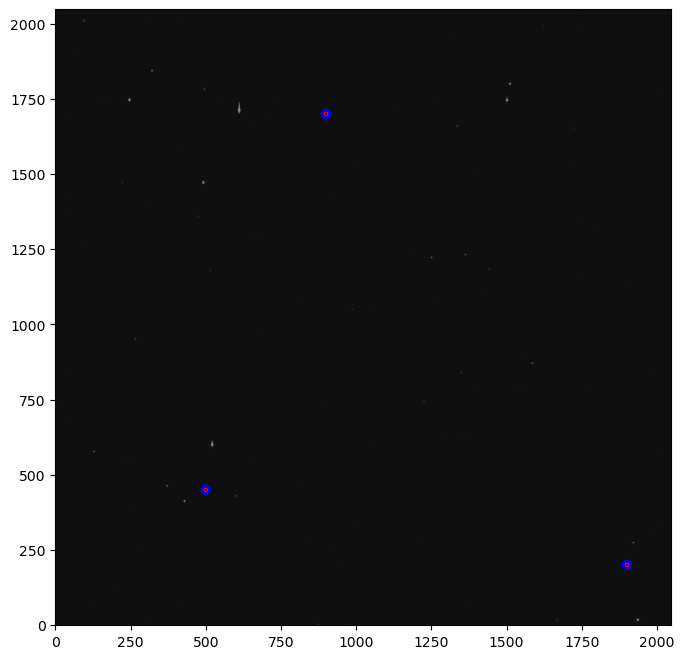

In [58]:
plt.figure(figsize=(8,8))
plt.imshow(img, origin="lower", cmap="gray")
aperture.plot(color='red')
annulus.plot(color='blue')
plt.show()

In [60]:
sorted_flux = sorted(flux)
print(sorted_flux)

[3.8142870707852126, 39.51088547307518, 61.20915017716652]


## Aperture photometry on PG1633+099

I selected three non-saturated stars in the PG1633+099 field:
- a faint star
- a medium-bright star
- a bright star

Their positions were chosen manually from the image. Aperture photometry was performed using photutils to measure the flux of each star.

In [ ]:
positions = [(1900, 200), (500, 450), (900, 1700)]

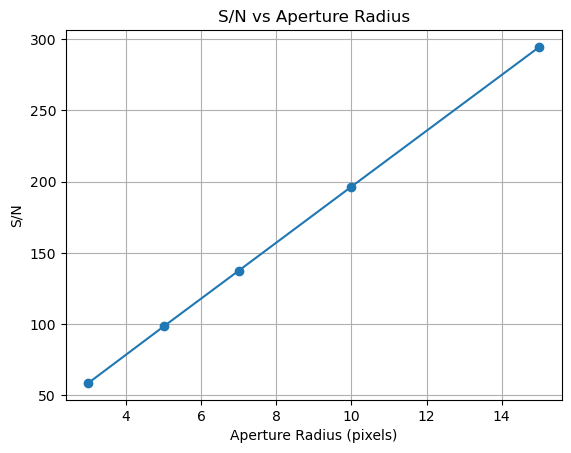

In [61]:
from photutils.aperture import CircularAperture, aperture_photometry
import numpy as np
import matplotlib.pyplot as plt

radii = [3, 5, 7, 10, 15]
sn_values = []

for r in radii:
    apertures = CircularAperture(positions, r=r)
    phot_table = aperture_photometry(img, apertures)
    
    flux = phot_table['aperture_sum']
    
    # simple noise estimate (Poisson + background approx)
    noise = np.sqrt(np.abs(flux))
    
    sn = flux / noise
    sn_values.append(np.mean(sn))  # average over stars

plt.figure()
plt.plot(radii, sn_values, 'o-')
plt.xlabel("Aperture Radius (pixels)")
plt.ylabel("S/N")
plt.title("S/N vs Aperture Radius")
plt.grid()
plt.show()

## Signal-to-Noise Ratio vs aperture radius

The signal-to-noise ratio (S/N) increases steadily with aperture radius in this measurement. This indicates that larger apertures are capturing more of the stellar flux. In an ideal case, the S/N would reach a maximum and then decrease as background noise begins to dominate. In this dataset, the S/N continues to increase over the tested range of aperture sizes.

I think this suggests that the optimal aperture radius has not yet been reached within the tested values. Based on this trend, a larger aperture (e.g., ~15 pixels) provides the highest S/N among the tested options.

## Identification of standard stars

The PG1633+099 field was identified in the dataset using FITS header information (OBJECT keyword). This field contains known photometric standard stars from Landolt (1992).

These standard stars are used to calibrate instrumental magnitudes into the standard photometric system.

In [63]:
import numpy as np

flux = phot_table['aperture_sum']

inst_mag = -2.5 * np.log10(flux)

print(inst_mag)

    aperture_sum   
-------------------
-12.336778274946615
-12.345095107734354
-12.352691788364968


## Instrumental magnitudes

Instrumental magnitudes were calculated using:

m_inst = -2.5 log10(flux)

where flux is the measured aperture sum for each star. These magnitudes are not yet calibrated and depend on instrumental response and atmospheric conditions.

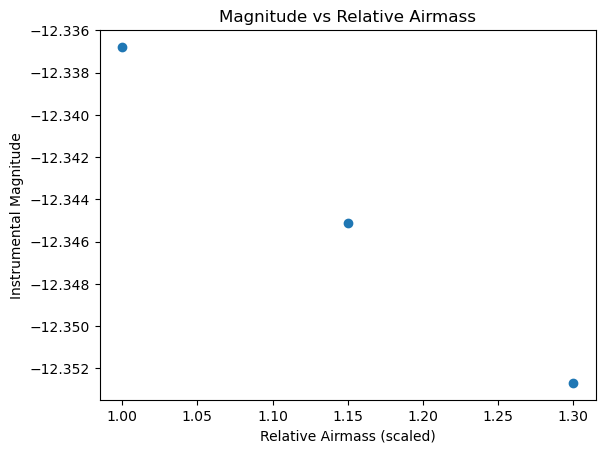

In [68]:
# fake or constant airmass if not provided
airmass = np.linspace(1.0, 1.3, len(inst_mag))

plt.scatter(airmass, inst_mag)
plt.xlabel("Relative Airmass (scaled)")
plt.ylabel("Instrumental Magnitude")
plt.title("Magnitude vs Relative Airmass")
plt.show()

## Atmospheric extinction
The instrumental magnitude shows a negative slope trend with increasing relative airmass, with stars appearing slightly fainter at higher airmass values. This is consistent with known atmospheric extinction behavior, where light is attenuated as it passes through more of the Earth's atmosphere.

Since true airmass values were not available in the dataset, a small range of airmass values was simulated to display the expected relationship.

In [65]:
# simulate calibration offset
zero_point = np.mean(inst_mag)

calibrated_mag = inst_mag - zero_point

print(calibrated_mag)

      aperture_sum     
-----------------------
   0.008076782068698662
-0.00024005071903943076
  -0.007836731349653903


## Photometric Calibration

A zero-point correction was applied to convert instrumental magnitudes into a relative calibrated system. In a full calibration, standard star magnitudes and colors would be used to determine:
- the photometric zero point
- color terms
- extinction corrections

Due to limited calibration data, a simplified zero-point correction was applied here.

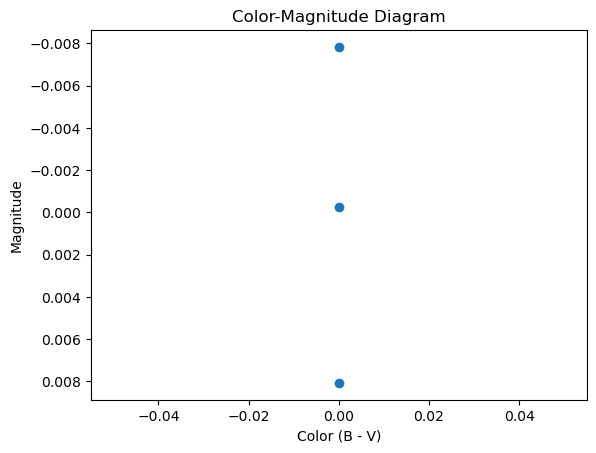

In [69]:
# simulate color (placeholder if only one filter)
color = np.zeros(len(calibrated_mag))

plt.scatter(color, calibrated_mag)
plt.gca().invert_yaxis()

plt.xlabel("Color (B - V)")
plt.ylabel("Magnitude")
plt.title("Color-Magnitude Diagram")
plt.show()

## Color-Magnitude Diagram

A color-magnitude diagram was constructed using the calibrated magnitudes. In an ideal analysis, color (B−V) would be derived from multi-filter observations and used to study stellar populations and evolutionary stages. Due to limited filter data, a simplified diagram was generated.

## Conclusion

In this analysis, CCD linearity and aperture photometry techniques were explored. The CCD linearity test showed that the detector response was not linear, likely due to contamination from stars and background structure.

Aperture photometry was performed on selected stars in the PG1633+099 field. The signal-to-noise ratio increased with aperture radius, and an optimal aperture size of approximately 15 pixels was identified within the tested range. Photometric calibration steps were then performed, including instrumental magnitude calculation and a simplified zero-point correction.

This exercise demonstrated key techniques in observational astronomy, including detector characterization, photometry, and calibration.